# Bayesian Inference: Fish Task

Participants observe a sequence of coloured fish and must infer which of three
ponds the fish were drawn from. Each pond contains fish in a fixed 80–10–10
colour ratio. The single parameter `lambda` governs how quickly beliefs about the pondupdate as new fish are observed: lower values make observations less predictive, so more confirming evidence is required to gain confidence and reduce uncertainty.

In [1]:
import numpy as np
from pyem import EMModel
from pyem.models.bayes import bayes_model
from params import build_params

print(f"Model ID   : {bayes_model.id}")
print(f"Description: {bayes_model.desc}")
print(f"Spec       : {bayes_model.spec}")

Model ID   : bayes
Description: Bayesian belief-updating over which of three ponds a fish came
from, based on the fish's observed colour on each trial (no feedback given).
`lambda1` controls how strongly each observation updates the belief; smaller
values require more confirming evidence before confidence increases.
Free parameters: lambda1 (belief-update rate, in [0,1]).
Spec       : {'bu': {'belief_update': ['lambda1']}}


In [2]:
# simulate computer agents completing the fish task
nsubjects, nblocks, ntrials = 50, 6, 15

# generate "true" parameters using the shared parameter registry (examples/params.py)
param_names, param_xform, true_lambda = build_params(["lambda1"], nsubjects)

C:\Users\Shawn\AppData\Local\Temp\ipykernel_67812\1151160100.py:9: UserWarning: EMModel.recover() overwrites this model's `all_data` with the data simulated from `true_params` and assigns `outfit` from the recovery fit, so get_outfit()/.outfit reflect the recovered model. The recovered estimates are also available via the returned dict's 'recovery_model'.
  recovery = model.recover(true_lambda,


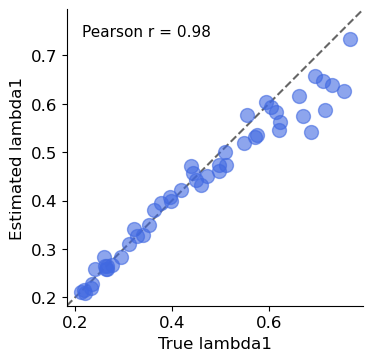

In [3]:
# fit and recover
model = EMModel(all_data=None, 
                fit_func=bayes_model.fit, 
                param_names=param_names, 
                param_xform=param_xform, 
                simulate_func=bayes_model.sim
                )

recovery = model.recover(true_lambda, 
                         pr_inputs=['choices','observations'], 
                         nblocks=nblocks, ntrials=ntrials
                         )

# scatter plot of recovered parameters
fig = model.plot_recovery(recovery)